In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [3]:
DATA_PATH = Path("../data/features/transaction_features.parquet")

df = pd.read_parquet(DATA_PATH)

print(f"Dataset shape: {df.shape}")

Dataset shape: (6362620, 25)


In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,is_cash_out,is_payment,is_cash_in,is_debit,origin_balance_change,origin_balance_error,destination_balance_change,destination_balance_error,hour_of_day,day
0,1,PAYMENT,"9,839.6396",C1231006815,"170,136.0000","160,296.3594",M1979787155,0.0000,0.0000,0,...,0,1,0,0,"9,839.6406",0.0010,0.0000,"-9,839.6396",1,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7207",M2044282225,0.0000,0.0000,0,...,0,1,0,0,"1,864.2793",-0.0007,0.0000,"-1,864.2800",1,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,...,0,0,0,0,181.0000,0.0000,0.0000,-181.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,...,1,0,0,0,181.0000,0.0000,"-21,182.0000","-21,363.0000",1,0
4,1,PAYMENT,"11,668.1396",C2048537720,"41,554.0000","29,885.8594",M1230701703,0.0000,0.0000,0,...,0,1,0,0,"11,668.1406",0.0010,0.0000,"-11,668.1396",1,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 25 columns):
 #   Column                      Dtype   
---  ------                      -----   
 0   step                        int32   
 1   type                        category
 2   amount                      float32 
 3   nameOrig                    str     
 4   oldbalanceOrg               float32 
 5   newbalanceOrig              float32 
 6   nameDest                    str     
 7   oldbalanceDest              float32 
 8   newbalanceDest              float32 
 9   isFraud                     int8    
 10  isFlaggedFraud              int8    
 11  amount_log                  float32 
 12  is_zero_amount              int8    
 13  is_high_value               int8    
 14  is_transfer                 int8    
 15  is_cash_out                 int8    
 16  is_payment                  int8    
 17  is_cash_in                  int8    
 18  is_debit                    int8    
 19  origin_bala

Overall Feature Summary

In [6]:
feature_columns = [
    "amount_log",
    "is_zero_amount",
    "is_high_value",
    "is_transfer",
    "is_cash_out",
    "is_payment",
    "is_cash_in",
    "is_debit",
    "origin_balance_change",
    "origin_balance_error",
    "destination_balance_change",
    "destination_balance_error",
    "hour_of_day",
    "day"
]

df[feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
amount_log,"6,362,620.0000",10.8409,1.8145,0.0000,9.5023,11.2235,12.2488,18.3421
is_zero_amount,"6,362,620.0000",0.0000,0.0016,0.0000,0.0000,0.0000,0.0000,1.0000
is_high_value,"6,362,620.0000",0.0100,0.0995,0.0000,0.0000,0.0000,0.0000,1.0000
is_transfer,"6,362,620.0000",0.0838,0.2770,0.0000,0.0000,0.0000,0.0000,1.0000
is_cash_out,"6,362,620.0000",0.3517,0.4775,0.0000,0.0000,0.0000,1.0000,1.0000
is_payment,"6,362,620.0000",0.3381,0.4731,0.0000,0.0000,0.0000,1.0000,1.0000
is_cash_in,"6,362,620.0000",0.2199,0.4142,0.0000,0.0000,0.0000,0.0000,1.0000
is_debit,"6,362,620.0000",0.0065,0.0804,0.0000,0.0000,0.0000,0.0000,1.0000
origin_balance_change,"6,362,620.0000","-21,230.5645","146,643.2812","-1,915,268.0000",0.0000,0.0000,"10,150.4355","10,000,002.0000"
origin_balance_error,"6,362,620.0000","-201,092.4844","606,650.4375","-92,445,520.0000","-249,641.1016","-68,677.2539","-2,954.1974",2.5298


Fraud vs Legitimate Feature Comparison

In [7]:
fraud_feature_comparison = (
    df.groupby("isFraud")[
        [
            "amount",
            "amount_log",
            "origin_balance_change",
            "origin_balance_error",
            "destination_balance_change",
            "destination_balance_error"
        ]
    ]
    .agg(["mean", "median", "std"])
)

fraud_feature_comparison

amount                             amount_log                 \
                  mean       median            std       mean  median    std   
isFraud                                                                        
0         178,197.0469  74,684.7188   596,236.9816    10.8382 11.2210 1.8128   
1       1,467,967.2500 441,423.4375 2,404,252.9475    12.8920 12.9978 1.9427   

        origin_balance_change                              \
                         mean       median            std   
isFraud                                                     
0                -23,141.5156       0.0000   106,223.3015   
1              1,457,274.8750 436,317.5000 2,396,099.1990   

        origin_balance_error                            \
                        mean       median          std   
isFraud                                                  
0              -201,338.5469 -69,049.3125 606,928.8910   
1               -10,692.3262       0.0000 265,146.1289   

        destination_balance_change                        \
                              mean median            std   
isFraud                                                    
0                     123,504.8125 0.0000   810,422.2716   
1                     735,458.0000 0.0000 1,856,983.8577   

        destination_balance_error                             
                             mean      median            std  
isFraud                                                       
0                    -54,692.2305 -3,500.6799   436,002.6326  
1                   -732,509.3125 -2,231.4600 1,867,747.9916

Analyze High-Value Transactions

In [8]:
high_value_analysis = (
    df.groupby("is_high_value")
    .agg(
        transactions=("isFraud", "count"),
        fraud_cases=("isFraud", "sum")
    )
)

high_value_analysis["fraud_rate"] = (
    high_value_analysis["fraud_cases"]
    / high_value_analysis["transactions"]
    * 100
)

high_value_analysis

,transactions,fraud_cases,fraud_rate
is_high_value,,,
0,6298993,6244,0.0991
1,63627,1969,3.0946


Balance Error Analysis

In [9]:
df["abs_origin_balance_error"] = (
    df["origin_balance_error"].abs()
)

df["abs_destination_balance_error"] = (
    df["destination_balance_error"].abs()
)

In [10]:
balance_error_analysis = (
    df.groupby("isFraud")
    .agg(
        transactions=("isFraud", "count"),
        avg_origin_error=(
            "abs_origin_balance_error",
            "mean"
        ),
        median_origin_error=(
            "abs_origin_balance_error",
            "median"
        ),
        avg_destination_error=(
            "abs_destination_balance_error",
            "mean"
        ),
        median_destination_error=(
            "abs_destination_balance_error",
            "median"
        )
    )
)

balance_error_analysis

,transactions,avg_origin_error,median_origin_error,avg_destination_error,median_destination_error
isFraud,,,,,
0,6354407,"201,338.5469","69,049.3125","92,756.9844","5,123.1099"
1,8213,"10,692.3291",0.0000,"745,138.6250","9,511.6904"


Strong Balance Anomaly Signal

In [11]:
df["has_origin_balance_anomaly"] = (
    df["abs_origin_balance_error"] > 1
).astype("int8")

df["has_destination_balance_anomaly"] = (
    df["abs_destination_balance_error"] > 1
).astype("int8")

In [12]:
origin_anomaly_analysis = (
    df.groupby("has_origin_balance_anomaly")
    .agg(
        transactions=("isFraud", "count"),
        fraud_cases=("isFraud", "sum")
    )
)

origin_anomaly_analysis["fraud_rate"] = (
    origin_anomaly_analysis["fraud_cases"]
    / origin_anomaly_analysis["transactions"]
    * 100
)

origin_anomaly_analysis

,transactions,fraud_cases,fraud_rate
has_origin_balance_anomaly,,,
0,1361817,8162,0.5993
1,5000803,51,0.0010


In [13]:
destination_anomaly_analysis = (
    df.groupby("has_destination_balance_anomaly")
    .agg(
        transactions=("isFraud", "count"),
        fraud_cases=("isFraud", "sum")
    )
)

destination_anomaly_analysis["fraud_rate"] = (
    destination_anomaly_analysis["fraud_cases"]
    / destination_anomaly_analysis["transactions"]
    * 100
)

destination_anomaly_analysis

,transactions,fraud_cases,fraud_rate
has_destination_balance_anomaly,,,
0,2531774,3968,0.1567
1,3830846,4245,0.1108


Transaction Type + Risk Signal

In [14]:
type_risk_analysis = (
    df.groupby("type")
    .agg(
        transactions=("isFraud", "count"),
        fraud_cases=("isFraud", "sum"),
        avg_amount=("amount", "mean"),
        avg_origin_error=(
            "abs_origin_balance_error",
            "mean"
        )
    )
)

type_risk_analysis["fraud_rate"] = (
    type_risk_analysis["fraud_cases"]
    / type_risk_analysis["transactions"]
    * 100
)

type_risk_analysis.sort_values(
    "fraud_rate",
    ascending=False
)

,transactions,fraud_cases,avg_amount,avg_origin_error,fraud_rate
type,,,,,
TRANSFER,532909,4097,"910,647.0000","866,493.3125",0.7688
CASH_OUT,2237500,4116,"176,273.9531","147,724.3594",0.1840
CASH_IN,1399284,0,"168,920.2500","337,835.4688",0.0000
DEBIT,41432,0,"5,483.6650","1,997.9818",0.0000
PAYMENT,2151495,0,"13,057.6045","6,678.6699",0.0000


High-value fraud signal

In [15]:
high_value_analysis

,transactions,fraud_cases,fraud_rate
is_high_value,,,
0,6298993,6244,0.0991
1,63627,1969,3.0946


Balance error analysis

In [16]:
balance_error_analysis

,transactions,avg_origin_error,median_origin_error,avg_destination_error,median_destination_error
isFraud,,,,,
0,6354407,"201,338.5469","69,049.3125","92,756.9844","5,123.1099"
1,8213,"10,692.3291",0.0000,"745,138.6250","9,511.6904"


Origin balance anomaly analysis

In [17]:
origin_anomaly_analysis

,transactions,fraud_cases,fraud_rate
has_origin_balance_anomaly,,,
0,1361817,8162,0.5993
1,5000803,51,0.0010


Analyze Destination Balance Anomaly

In [18]:
destination_anomaly_analysis

,transactions,fraud_cases,fraud_rate
has_destination_balance_anomaly,,,
0,2531774,3968,0.1567
1,3830846,4245,0.1108


Transaction Type × High Value

In [19]:
multi_signal_analysis = (
    df.groupby(["type", "is_high_value"])
    .agg(
        transactions=("isFraud", "count"),
        fraud_cases=("isFraud", "sum"),
        total_amount=("amount", "sum")
    )
    .reset_index()
)

multi_signal_analysis["fraud_rate"] = (
    multi_signal_analysis["fraud_cases"]
    / multi_signal_analysis["transactions"]
    * 100
)

multi_signal_analysis.sort_values(
    "fraud_rate",
    ascending=False
)

,type,is_high_value,transactions,fraud_cases,total_amount,fraud_rate
3,CASH_OUT,1,1032,978,"4,830,985,216.0000",94.7674
7,TRANSFER,1,62590,991,"244,563,279,872.0000",1.5833
6,TRANSFER,0,470319,3106,"240,728,719,360.0000",0.6604
2,CASH_OUT,0,2236468,3138,"389,581,996,032.0000",0.1403
0,CASH_IN,0,1399279,0,"236,358,418,432.0000",0.0000
1,CASH_IN,1,5,0,"8,976,212.0000",0.0000
5,PAYMENT,0,2151495,0,"28,093,370,368.0000",0.0000
4,DEBIT,0,41432,0,"227,199,216.0000",0.0000


Transfer + Cash Out Risk

In [20]:
df["high_risk_transaction_type"] = (
    df["type"].isin(["TRANSFER", "CASH_OUT"])
).astype("int8")

In [21]:
risk_type_analysis = (
    df.groupby("high_risk_transaction_type")
    .agg(
        transactions=("isFraud", "count"),
        fraud_cases=("isFraud", "sum")
    )
)

risk_type_analysis["fraud_rate"] = (
    risk_type_analysis["fraud_cases"]
    / risk_type_analysis["transactions"]
    * 100
)

risk_type_analysis

,transactions,fraud_cases,fraud_rate
high_risk_transaction_type,,,
0,3592211,0,0.0000
1,2770409,8213,0.2965


In [22]:
destination_anomaly_analysis


,transactions,fraud_cases,fraud_rate
has_destination_balance_anomaly,,,
0,2531774,3968,0.1567
1,3830846,4245,0.1108


In [23]:

multi_signal_analysis.sort_values("fraud_rate", ascending=False)


,type,is_high_value,transactions,fraud_cases,total_amount,fraud_rate
3,CASH_OUT,1,1032,978,"4,830,985,216.0000",94.7674
7,TRANSFER,1,62590,991,"244,563,279,872.0000",1.5833
6,TRANSFER,0,470319,3106,"240,728,719,360.0000",0.6604
2,CASH_OUT,0,2236468,3138,"389,581,996,032.0000",0.1403
0,CASH_IN,0,1399279,0,"236,358,418,432.0000",0.0000
1,CASH_IN,1,5,0,"8,976,212.0000",0.0000
5,PAYMENT,0,2151495,0,"28,093,370,368.0000",0.0000
4,DEBIT,0,41432,0,"227,199,216.0000",0.0000


In [24]:

risk_type_analysis

,transactions,fraud_cases,fraud_rate
high_risk_transaction_type,,,
0,3592211,0,0.0000
1,2770409,8213,0.2965


Time-Based Fraud Analysis

In [25]:
hourly_fraud_analysis = (
    df.groupby("hour_of_day")
    .agg(
        transactions=("isFraud", "count"),
        fraud_cases=("isFraud", "sum")
    )
)

hourly_fraud_analysis["fraud_rate"] = (
    hourly_fraud_analysis["fraud_cases"]
    / hourly_fraud_analysis["transactions"]
    * 100
)

hourly_fraud_analysis = hourly_fraud_analysis.sort_values(
    "fraud_rate",
    ascending=False
)

hourly_fraud_analysis

,transactions,fraud_cases,fraud_rate
hour_of_day,,,
5,1641,366,22.3035
4,1241,274,22.0790
3,2007,326,16.2431
6,3420,358,10.4678
2,9018,372,4.1251
7,8988,328,3.6493
8,26915,368,1.3673
1,27111,358,1.3205
0,71587,300,0.4191


Visualize Hourly Fraud Risk

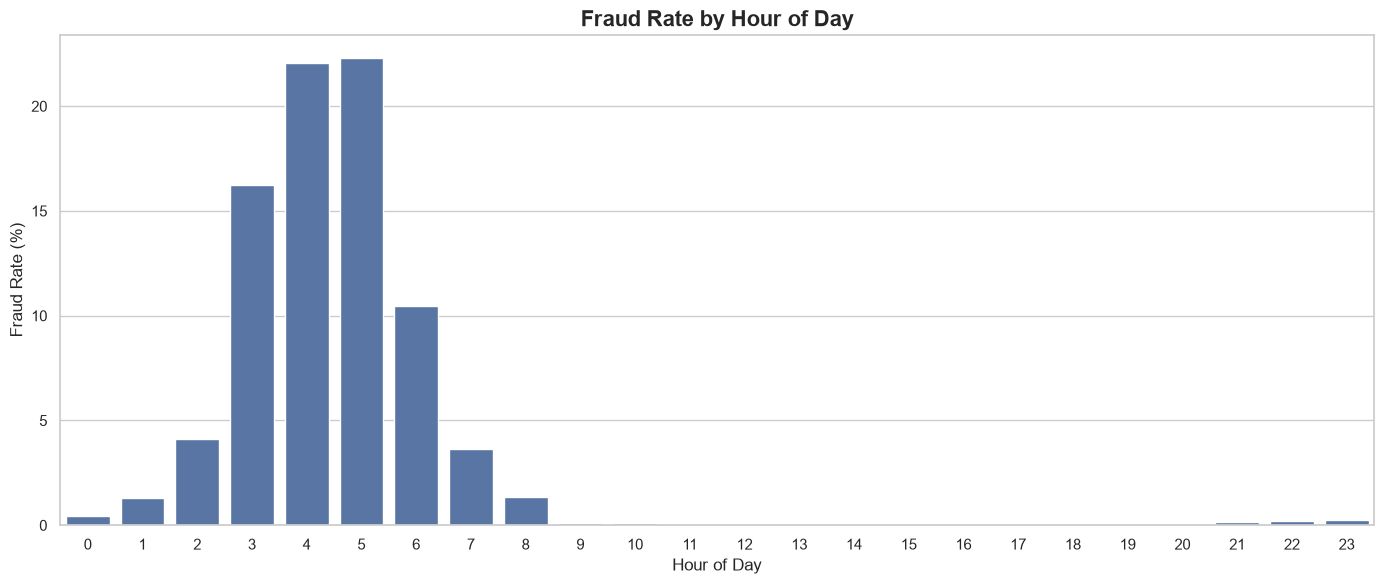

In [26]:
hourly_plot = hourly_fraud_analysis.sort_index()

plt.figure(figsize=(14, 6))

sns.barplot(
    data=hourly_plot.reset_index(),
    x="hour_of_day",
    y="fraud_rate"
)

plt.title(
    "Fraud Rate by Hour of Day",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()

plt.show()

Fraud by Day

In [27]:
daily_fraud_analysis = (
    df.groupby("day")
    .agg(
        transactions=("isFraud", "count"),
        fraud_cases=("isFraud", "sum")
    )
)

daily_fraud_analysis["fraud_rate"] = (
    daily_fraud_analysis["fraud_cases"]
    / daily_fraud_analysis["transactions"]
    * 100
)

daily_fraud_analysis.sort_values(
    "fraud_rate",
    ascending=False
).head(20)

,transactions,fraud_cases,fraud_rate
day,,,
30,282,282,100.0000
2,6749,306,4.5340
26,8574,276,3.2190
29,11283,264,2.3398
18,11286,242,2.1442
25,13893,280,2.0154
4,12995,244,1.8776
27,14522,254,1.7491
19,19739,248,1.2564


Visualize Fraud Rate Over Time

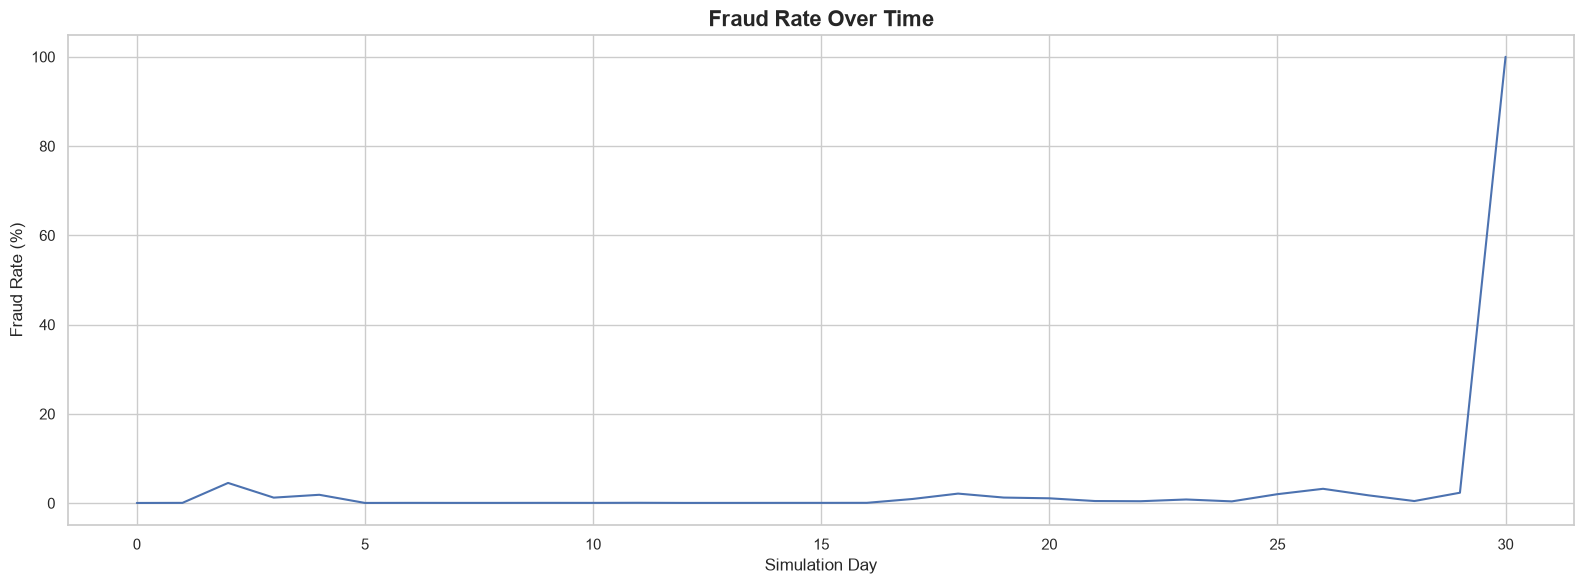

In [28]:
daily_plot = daily_fraud_analysis.sort_index()

plt.figure(figsize=(16, 6))

plt.plot(
    daily_plot.index,
    daily_plot["fraud_rate"]
)

plt.title(
    "Fraud Rate Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Simulation Day")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()

plt.show()

In [29]:
hourly_fraud_analysis

,transactions,fraud_cases,fraud_rate
hour_of_day,,,
5,1641,366,22.3035
4,1241,274,22.0790
3,2007,326,16.2431
6,3420,358,10.4678
2,9018,372,4.1251
7,8988,328,3.6493
8,26915,368,1.3673
1,27111,358,1.3205
0,71587,300,0.4191


In [30]:
daily_fraud_analysis.sort_values(
    "fraud_rate",
    ascending=False
).head(20)

,transactions,fraud_cases,fraud_rate
day,,,
30,282,282,100.0000
2,6749,306,4.5340
26,8574,276,3.2190
29,11283,264,2.3398
18,11286,242,2.1442
25,13893,280,2.0154
4,12995,244,1.8776
27,14522,254,1.7491
19,19739,248,1.2564


Create Account-Level Features

In [31]:
origin_stats = (
    df.groupby("nameOrig")
    .agg(
        origin_transaction_count=("amount", "count"),
        origin_total_amount=("amount", "sum"),
        origin_average_amount=("amount", "mean"),
        origin_max_amount=("amount", "max")
    )
)

origin_stats.head()

,origin_transaction_count,origin_total_amount,origin_average_amount,origin_max_amount
nameOrig,,,,
C1000000639,1,"244,486.4531","244,486.4531","244,486.4531"
C1000001337,1,"3,170.2800","3,170.2800","3,170.2800"
C1000001725,1,"8,424.7402","8,424.7402","8,424.7402"
C1000002591,1,"261,877.1875","261,877.1875","261,877.1875"
C1000003372,1,"20,528.6504","20,528.6504","20,528.6504"


In [32]:
df = df.join(
    origin_stats,
    on="nameOrig"
)

In [33]:
df[
    [
        "nameOrig",
        "amount",
        "origin_transaction_count",
        "origin_total_amount",
        "origin_average_amount",
        "origin_max_amount"
    ]
].head(10)

,nameOrig,amount,origin_transaction_count,origin_total_amount,origin_average_amount,origin_max_amount
0,C1231006815,"9,839.6396",1,"9,839.6396","9,839.6396","9,839.6396"
1,C1666544295,"1,864.2800",1,"1,864.2800","1,864.2800","1,864.2800"
2,C1305486145,181.0000,1,181.0000,181.0000,181.0000
3,C840083671,181.0000,1,181.0000,181.0000,181.0000
4,C2048537720,"11,668.1396",1,"11,668.1396","11,668.1396","11,668.1396"
5,C90045638,"7,817.7100",1,"7,817.7100","7,817.7100","7,817.7100"
6,C154988899,"7,107.7700",1,"7,107.7700","7,107.7700","7,107.7700"
7,C1912850431,"7,861.6401",1,"7,861.6401","7,861.6401","7,861.6401"
8,C1265012928,"4,024.3601",1,"4,024.3601","4,024.3601","4,024.3601"
9,C712410124,"5,337.7700",1,"5,337.7700","5,337.7700","5,337.7700"


Behavioral Deviation

In [34]:
df["amount_vs_origin_average"] = (
    df["amount"]
    / df["origin_average_amount"].replace(0, np.nan)
)

In [35]:
df["amount_vs_origin_max"] = (
    df["amount"]
    / df["origin_max_amount"].replace(0, np.nan)
)

In [36]:
df[
    [
        "amount",
        "origin_average_amount",
        "amount_vs_origin_average",
        "amount_vs_origin_max",
        "isFraud"
    ]
].describe()

,amount,origin_average_amount,amount_vs_origin_average,amount_vs_origin_max,isFraud
count,"6,362,620.0000","6,362,620.0000","6,362,604.0000","6,362,604.0000","6,362,620.0000"
mean,"179,861.8906","179,861.8906",1.0000,0.9989,0.0013
std,"603,858.2500","603,258.1250",0.0377,0.0294,0.0359
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,"13,389.5703","13,425.0972",1.0000,1.0000,0.0000
50%,"74,871.9375","75,064.6602",1.0000,1.0000,0.0000
75%,"208,721.4805","208,676.1211",1.0000,1.0000,0.0000
max,"92,445,520.0000","92,445,520.0000",2.7778,1.0000,1.0000


In [37]:
origin_stats.head()

,origin_transaction_count,origin_total_amount,origin_average_amount,origin_max_amount
nameOrig,,,,
C1000000639,1,"244,486.4531","244,486.4531","244,486.4531"
C1000001337,1,"3,170.2800","3,170.2800","3,170.2800"
C1000001725,1,"8,424.7402","8,424.7402","8,424.7402"
C1000002591,1,"261,877.1875","261,877.1875","261,877.1875"
C1000003372,1,"20,528.6504","20,528.6504","20,528.6504"


In [38]:
df[
    [
        "nameOrig",
        "amount",
        "origin_transaction_count",
        "origin_total_amount",
        "origin_average_amount",
        "origin_max_amount"
    ]
].head(10)

,nameOrig,amount,origin_transaction_count,origin_total_amount,origin_average_amount,origin_max_amount
0,C1231006815,"9,839.6396",1,"9,839.6396","9,839.6396","9,839.6396"
1,C1666544295,"1,864.2800",1,"1,864.2800","1,864.2800","1,864.2800"
2,C1305486145,181.0000,1,181.0000,181.0000,181.0000
3,C840083671,181.0000,1,181.0000,181.0000,181.0000
4,C2048537720,"11,668.1396",1,"11,668.1396","11,668.1396","11,668.1396"
5,C90045638,"7,817.7100",1,"7,817.7100","7,817.7100","7,817.7100"
6,C154988899,"7,107.7700",1,"7,107.7700","7,107.7700","7,107.7700"
7,C1912850431,"7,861.6401",1,"7,861.6401","7,861.6401","7,861.6401"
8,C1265012928,"4,024.3601",1,"4,024.3601","4,024.3601","4,024.3601"
9,C712410124,"5,337.7700",1,"5,337.7700","5,337.7700","5,337.7700"


In [39]:
df[
    [
        "amount",
        "origin_average_amount",
        "amount_vs_origin_average",
        "amount_vs_origin_max",
        "isFraud"
    ]
].describe()

,amount,origin_average_amount,amount_vs_origin_average,amount_vs_origin_max,isFraud
count,"6,362,620.0000","6,362,620.0000","6,362,604.0000","6,362,604.0000","6,362,620.0000"
mean,"179,861.8906","179,861.8906",1.0000,0.9989,0.0013
std,"603,858.2500","603,258.1250",0.0377,0.0294,0.0359
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,"13,389.5703","13,425.0972",1.0000,1.0000,0.0000
50%,"74,871.9375","75,064.6602",1.0000,1.0000,0.0000
75%,"208,721.4805","208,676.1211",1.0000,1.0000,0.0000
max,"92,445,520.0000","92,445,520.0000",2.7778,1.0000,1.0000


Sort transactions by time

In [40]:
df = df.sort_values(
    ["nameOrig", "step"]
).copy()

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,abs_destination_balance_error,has_origin_balance_anomaly,has_destination_balance_anomaly,high_risk_transaction_type,origin_transaction_count,origin_total_amount,origin_average_amount,origin_max_amount,amount_vs_origin_average,amount_vs_origin_max
3196942,249,CASH_OUT,"244,486.4531",C1000000639,"8,946.0000",0.0000,C785826240,"526,950.3750","771,436.8125",0,...,0.0156,1,0,1,1,"244,486.4531","244,486.4531","244,486.4531",1.0000,1.0000
2798983,217,PAYMENT,"3,170.2800",C1000001337,"58,089.0000","54,918.7188",M216466820,0.0000,0.0000,0,...,"3,170.2800",0,1,0,1,"3,170.2800","3,170.2800","3,170.2800",1.0000,1.0000
1013585,46,PAYMENT,"8,424.7402",C1000001725,783.0000,0.0000,M1974356374,0.0000,0.0000,0,...,"8,424.7402",1,1,0,1,"8,424.7402","8,424.7402","8,424.7402",1.0000,1.0000
2980283,231,CASH_IN,"261,877.1875",C1000002591,"7,596.0000","269,473.1875",C503690069,"1,126,627.7500","864,750.5000",0,...,"523,754.4375",1,1,0,1,"261,877.1875","261,877.1875","261,877.1875",1.0000,1.0000
1920204,167,CASH_IN,"20,528.6504",C1000003372,"2,302,074.0000","2,322,602.7500",C1840417793,"82,696.1719","62,167.5195",0,...,"41,057.3047",1,1,0,1,"20,528.6504","20,528.6504","20,528.6504",1.0000,1.0000


Create previous transaction count

In [41]:
df["origin_previous_count"] = (
    df.groupby("nameOrig")
      .cumcount()
)

In [42]:
df[
    [
        "nameOrig",
        "step",
        "amount",
        "origin_previous_count",
        "isFraud"
    ]
].head(20)

,nameOrig,step,amount,origin_previous_count,isFraud
3196942,C1000000639,249,"244,486.4531",0,0
2798983,C1000001337,217,"3,170.2800",0,0
1013585,C1000001725,46,"8,424.7402",0,0
2980283,C1000002591,231,"261,877.1875",0,0
1920204,C1000003372,167,"20,528.6504",0,0
3374567,C1000003615,254,"49,360.7695",0,0
4548211,C1000004053,327,"211,189.6406",0,0
847860,C1000004530,41,"93,865.1328",0,0
2825292,C1000005353,226,"3,228,390.0000",0,0
2202461,C1000005555,185,"233,109.7969",0,0


Previous total amount

In [ ]:
df["origin_previous_total_amount"] = (
    df.groupby("nameOrig")["amount"]
      .transform(lambda x: x.shift(1).expanding().sum())
)

Previous average amount

In [ ]:
df["origin_previous_average_amount"] = (
    df.groupby("nameOrig")["amount"]
      .transform(lambda x: x.shift(1).expanding().mean())
)

Amount deviation

In [ ]:
df["amount_vs_previous_average"] = (
    df["amount"]
    / df["origin_previous_average_amount"]
)